In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Setting gaya visual untuk grafik EDA
sns.set_theme(style="whitegrid")

In [ ]:
# Ganti nama file sesuai dengan path dataset Anda
file_path = "/content/Book2.xlsx"

# Membaca dataset
xls = pd.read_excel(file_path)
df = pd.read_excel(file_path)

# Menampilkan 5 baris pertama untuk memastikan data termuat
df.head()

,tanggal_publish,year,creator,source,konten_asli,text,sentiment
0,2022-09-20 00:00:00,2022,KATADATAcoid,X,UU Perlindungan Data Pribadi akan disahkan ole...,NaN,neutral
1,2022-02-07 00:00:00,2022,Prabu_dasamuka,X,Semoga RUU PDP dapat segera disahkan menjadi U...,NaN,positive
2,2022-03-11 00:00:00,2022,anak_legal,X,Masalah kaya gini bakal bisa beres kalau RUU P...,NaN,positive
3,2022-01-09 00:00:00,2022,smartfmjogja,X,#SemangatPagiJogja | https://t.co/HcBEQd3O6q| ...,NaN,positive
4,2022-02-17 00:00:00,2022,HukumOnline,X,Koalisi Advokasi Pelindungan Data Pribadi mend...,NaN,negative


In [ ]:
import re

stopwords_id = set([
    "yang", "di", "ke", "dari", "pada", "dalam", "untuk", "dengan",
    "ini", "itu", "dan", "atau", "juga", "sebagai", "adalah", "bahwa",
    "oleh", "tersebut", "akan", "telah", "bisa", "ada"
])

news_stopwords = {
    "baca", "juga", "selengkapnya", "selanjutnya", "lainnya", "scroll",
    "continued", "content", "video", "tautan", "kompas", "detik",
    "detikcom", "kompascom", "com", "co", "id", "jakarta", "menurut",
    "ujar", "ungkap", "katanya", "kata", "hal", "yakni", "sementara",
    "hingga", "namun", "selain", "termasuk", "advertisement", "ads",
    "iklan", "melalui", "continue"
}
stopwords_id.update(news_stopwords)

negations = {"tidak", "bukan", "belum", "jangan"}
stopwords_id = stopwords_id - negations

important_short_words = {"ai", "it", "uu", "tv", "bi"}

def terpadu_preprocessing(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()

    # Menghapus URL, HTML, dan Mention
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'@\w+', ' ', text)

    # Menghapus Identitas Redaksional
    text = re.sub(r'\b[a-z]+\s*,\s*[a-z0-9\.]+\s*-', ' ', text)
    text = re.sub(r'\b[a-z]+\s*,\s*cnn indonesia\s*-', ' ', text)
    text = re.sub(r'\b[a-z]+\s*,\s*[a-z0-9\.\s]{3,20}\s*-', ' ', text)

    # Menghapus Boilerplate Pattern Spesifik
    boilerplate_patterns = [
        r"baca juga", r"lihat juga", r"lihat selengkapnya", r"lihat lainnya",
        r"scroll untuk melanjutkan", r"scroll ke bawah", r"simak video",
        r"tonton video", r"klik di sini", r"baca selengkapnya"
    ]
    for pattern in boilerplate_patterns:
        text = re.sub(pattern, " ", text)

    # Mengubah Tanda baca menjadi spasi (angka 0-9 dan titik untuk desimal tetap dipertahankan disini)
    # Modified to include '.' to preserve decimal numbers like '3.2'
    text = re.sub(r"[^a-z0-9.\s]", " ", text)

    words = []
    for word in text.split():
        if word not in stopwords_id:
            # === BAGIAN YANG DIPERBAIKI ===
            # Simpan kata jika: panjang > 2 ATAU masuk daftar kata penting ATAU mengandung angka
            # The `re.search(r'\d', word)` condition handles words containing digits, including decimals.
            if len(word) > 2 or word in important_short_words or re.search(r'\d', word):
                words.append(word)
            # ==============================

    return ' '.join(words)

# Terapkan ke dataset
df['clean_text'] = df['konten_asli'].apply(terpadu_preprocessing)
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

print("Preprocessing selesai! Angka dan desimal tetap aman.")
df[['konten_asli', 'clean_text']].head()

Preprocessing selesai! Angka dan desimal tetap aman.


,konten_asli,clean_text
0,UU Perlindungan Data Pribadi akan disahkan ole...,uu perlindungan data pribadi disahkan dpr hari...
1,Semoga RUU PDP dapat segera disahkan menjadi U...,semoga ruu pdp dapat segera disahkan menjadi u...
2,Masalah kaya gini bakal bisa beres kalau RUU P...,masalah kaya gini bakal beres kalau ruu perlin...
3,#SemangatPagiJogja | https://t.co/HcBEQd3O6q| ...,semangatpagijogja koalisi perlindungan data pr...
4,Koalisi Advokasi Pelindungan Data Pribadi mend...,koalisi advokasi pelindungan data pribadi mend...


/tmp/ipykernel_5441/1904628870.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', order=df['sentiment'].value_counts().index, palette='viridis')
/tmp/ipykernel_5441/1904628870.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='magma')


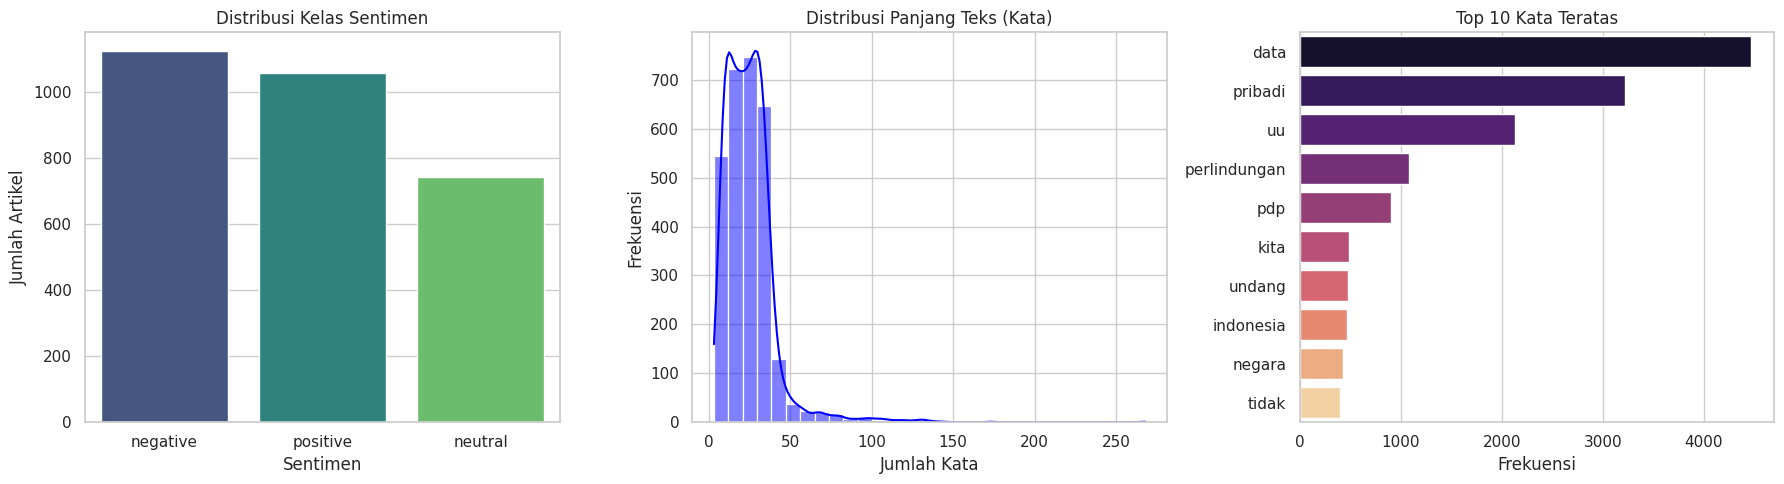

In [ ]:
# Membuat figure untuk visualisasi
plt.figure(figsize=(18, 5))

# 1. Distribusi Kelas Sentimen
plt.subplot(1, 3, 1)
sns.countplot(data=df, x='sentiment', order=df['sentiment'].value_counts().index, palette='viridis')
plt.title('Distribusi Kelas Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Artikel')

# 2. Distribusi Panjang Teks (Jumlah Kata)
plt.subplot(1, 3, 2)
sns.histplot(df['word_count'], bins=30, kde=True, color='blue')
plt.title('Distribusi Panjang Teks (Kata)')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')

# 3. Ekstraksi Top 10 Kata yang Paling Sering Muncul
all_words = ' '.join(df['clean_text']).split()
top_words = Counter(all_words).most_common(10)
words, counts = zip(*top_words)

plt.subplot(1, 3, 3)
sns.barplot(x=list(counts), y=list(words), palette='magma')
plt.title('Top 10 Kata Teratas')
plt.xlabel('Frekuensi')

plt.tight_layout()
plt.savefig('/content/eda_plots.png') # Save the figure
plt.show()

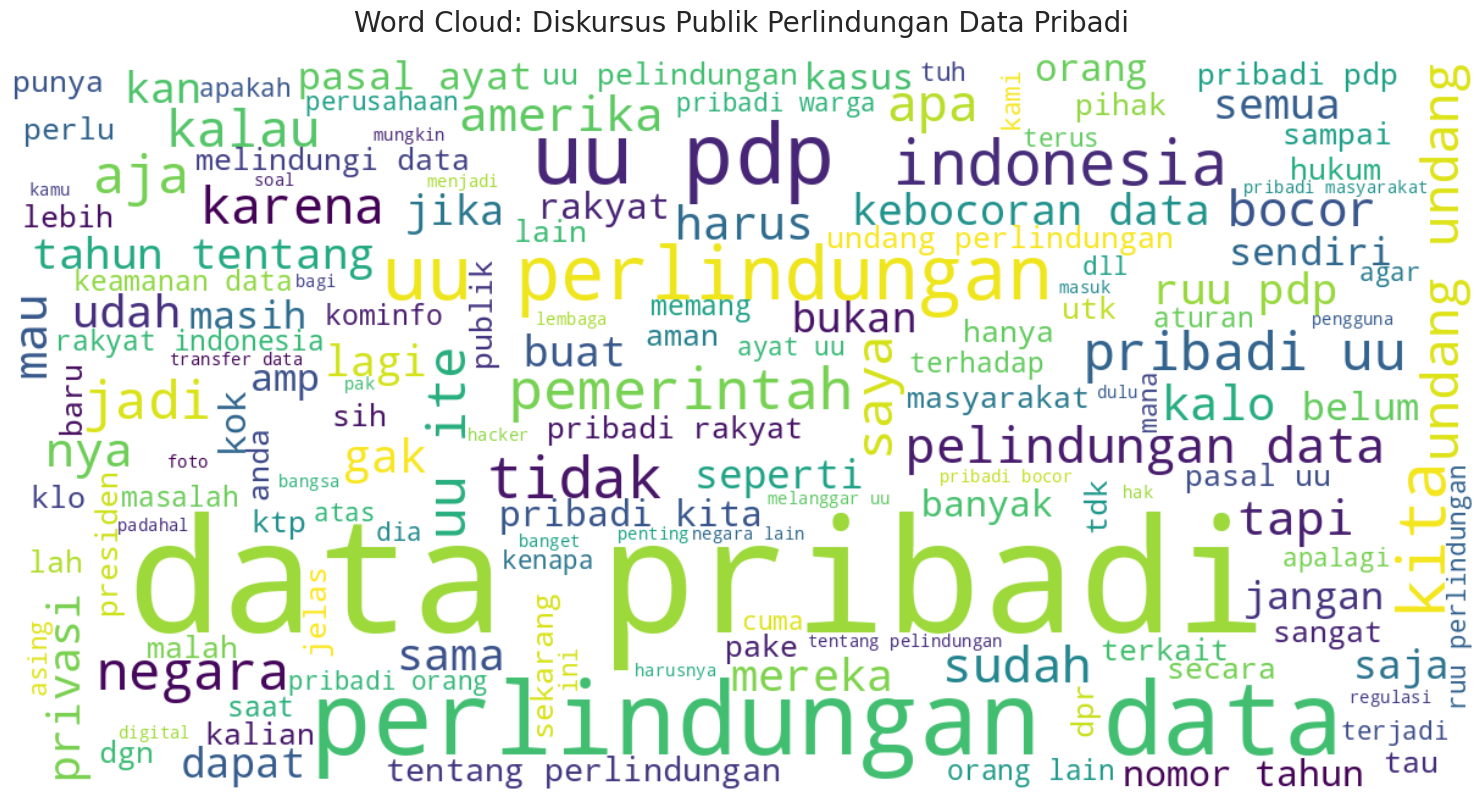

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud # Tambahkan baris ini

# Setting gaya visual untuk grafik EDA
sns.set_theme(style="whitegrid")

# Menggabungkan seluruh teks bersih menjadi satu string raksasa
all_text = ' '.join(df['clean_text'].dropna().tolist())

# Membuat objek WordCloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis', # Bisa diganti dengan 'magma', 'plasma', atau 'inferno'
    max_words=150,      # Batas maksimal kata yang ditampilkan
    contour_width=3,
    contour_color='steelblue'
).generate(all_text)

# Menampilkan Word Cloud
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud: Diskursus Publik Perlindungan Data Pribadi', fontsize=20, pad=20)
plt.axis('off') # Menghilangkan sumbu x dan y agar lebih rapi
plt.tight_layout()
plt.savefig('/content/wordcloud.png') # Save the figure
plt.show()

In [ ]:
import shutil
import os

source_plots = ["/content/eda_plots.png", "/content/wordcloud.png"]
destination_folder = "/content/drive/MyDrive/Visualisasi_Data/" # Changed to a specific folder

# Create the destination folder if it doesn't exist
os.makedirs(destination_folder, exist_ok=True)

for plot_path in source_plots:
    destination_path = os.path.join(destination_folder, os.path.basename(plot_path))
    shutil.copy(plot_path, destination_path)
    print(f"Figure '{os.path.basename(plot_path)}' saved to '{destination_folder}'")

Figure 'eda_plots.png' saved to '/content/drive/MyDrive/Visualisasi_Data/'
Figure 'wordcloud.png' saved to '/content/drive/MyDrive/Visualisasi_Data/'


In [ ]:
output_file_path = "/content/preprocessed_data_sosmed.xlsx"
df.to_excel(output_file_path, index=False)
print(f"Preprocessing results saved to {output_file_path}")

Preprocessing results saved to /content/preprocessed_data_sosmed.xlsx


In [ ]:
import os
import shutil
from google.colab import drive

mount_point = '/content/drive'

# Check if the directory exists and is NOT an active mount point. If so, clear its contents.
if os.path.exists(mount_point) and not os.path.ismount(mount_point):
    print(f"'{mount_point}' exists but is not an active mount point. Clearing contents...")
    try:
        shutil.rmtree(mount_point)
        os.makedirs(mount_point) # Recreate empty directory
    except Exception as e:
        print(f"Error clearing mount point: {e}")
elif not os.path.exists(mount_point):
    os.makedirs(mount_point)

drive.mount(mount_point, force_remount=True)

'/content/drive' exists but is not an active mount point. Clearing contents...
Mounted at /content/drive


In [ ]:
import shutil

source_path = "/content/preprocessed_data_sosmed.xlsx"
destination_folder = "/content/drive/MyDrive/"

# Ensure the destination folder exists
import os
os.makedirs(destination_folder, exist_ok=True)

destination_path = os.path.join(destination_folder, os.path.basename(source_path))

shutil.copy(source_path, destination_path)
print(f"File '{os.path.basename(source_path)}' saved to '{destination_folder}'")

File 'preprocessed_data_sosmed.xlsx' saved to '/content/drive/MyDrive/'


## Statistik Dataset

### Informasi Umum Dataset

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925 entries, 0 to 2924
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tanggal_publish  2925 non-null   object 
 1   year             2925 non-null   int64  
 2   creator          2925 non-null   object 
 3   source           2925 non-null   object 
 4   konten_asli      2925 non-null   object 
 5   text             0 non-null      float64
 6   sentiment        2925 non-null   object 
 7   clean_text       2925 non-null   object 
 8   word_count       2925 non-null   int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 205.8+ KB
None


### Statistik Deskriptif untuk Kolom Numerik

In [ ]:
display(df.describe())

,year,text,word_count
count,2925.000000,0.0,2925.000000
mean,2022.871111,NaN,24.721368
std,1.914593,NaN,16.315858
min,2020.000000,NaN,3.000000
25%,2021.000000,NaN,14.000000
50%,2023.000000,NaN,23.000000
75%,2025.000000,NaN,31.000000
max,2025.000000,NaN,268.000000


### Jumlah Nilai Hilang (Missing Values)

In [ ]:
display(df.isnull().sum().to_frame(name='Missing Values'))

,Missing Values
tanggal_publish,0
year,0
creator,0
source,0
konten_asli,0
text,2925
sentiment,0
clean_text,0
word_count,0


### Statistik untuk Kolom Kategorikal

In [ ]:
print("Value counts for 'source' column:")
display(df['source'].value_counts().to_frame())

print("\nValue counts for 'sentiment' column:")
display(df['sentiment'].value_counts().to_frame())

Value counts for 'source' column:


,count
source,
X,1911
YouTube,1014



Value counts for 'sentiment' column:


,count
sentiment,
negative,1125
positive,1057
neutral,743
